In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install lime

Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:
!pip install pytorch-tabnet

In [ ]:
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch version: 2.6.0+cu118
CUDA available: True


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import LabelEncoder

In [ ]:
netphish = pd.read_csv('/content/NetPhish_V3.csv')

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

# Step 1: Don't convert to .values so we keep column names
X = netphish.drop('class', axis=1)
y = netphish['class']

# Step 2: Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Step 3: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Step 4: Train-test split
X_train_full, X_test_full, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

# Step 5: RFE with RandomForest
model = RandomForestClassifier(random_state=42)
rfe = RFE(model, n_features_to_select=20)
rfe.fit(X_train_full, y_train)

# Step 6: Select top features
selected_features = X.columns[rfe.support_]
X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

# Step 7: Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=64)

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

model = MLP(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(20):
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

# Evaluation
model.eval()
with torch.no_grad():
    preds = model(X_test_tensor)
    y_pred = preds.argmax(dim=1).numpy()

print("MLP Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")


MLP Performance:
Accuracy: 0.9457
Precision: 0.9532
Recall: 0.9366
F1 Score: 0.9448


In [ ]:
class CNN1D(nn.Module):
    def __init__(self, input_dim):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3)
        self.fc1 = nn.Linear((input_dim - 4) * 32, 64)
        self.out = nn.Linear(64, 2)

    def forward(self, x):
    # assume input already has shape (batch_size, 1, seq_len)
      x = F.relu(self.conv1(x))
      x = F.relu(self.conv2(x))
      x = x.view(x.size(0), -1)
      x = F.relu(self.fc1(x))
      return self.out(x)


cnn_model = CNN1D(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

# Training CNN
for epoch in range(20):
    cnn_model.train()
    for xb, yb in train_dl:
        xb = xb.unsqueeze(1)  # Add channel dimension: (batch_size, 1, seq_len)
        optimizer.zero_grad()
        preds = cnn_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

# Evaluation
cnn_model.eval()
with torch.no_grad():
    preds = cnn_model(X_test_tensor.unsqueeze(1))  # Add channel dimension here
    y_pred = preds.argmax(dim=1).numpy()


print("1D CNN Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

1D CNN Performance:
Accuracy: 0.9488
Precision: 0.9511
Recall: 0.9454
F1 Score: 0.9482


In [ ]:
def cnn_predict_proba(input_numpy):
    model_input = torch.tensor(input_numpy, dtype=torch.float32)
    if model_input.dim() == 2:  # (N, features)
        model_input = model_input.unsqueeze(1)  # add channel dim
    cnn_model.eval()
    with torch.no_grad():
        outputs = cnn_model(model_input)
        probs = F.softmax(outputs, dim=1)
    return probs.cpu().numpy()


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
# LIME
lime_explainer = LimeTabularExplainer(X_train.values, feature_names=selected_features, class_names=['Legitimate', 'Phishing'], discretize_continuous=True)

exp = lime_explainer.explain_instance(X_test.iloc[0].values, cnn_predict_proba, num_features=len(selected_features))
exp.show_in_notebook(show_table=True)

  0%|          | 0/2500 [00:00<?, ?it/s]

X_test_subset shape: (2500, 20)
shap_values type: <class 'numpy.ndarray'>
Number of classes (length of shap_values): 2500
Shape of shap_values[0]: (20, 2)
Shape of shap_values[1]: (20, 2)


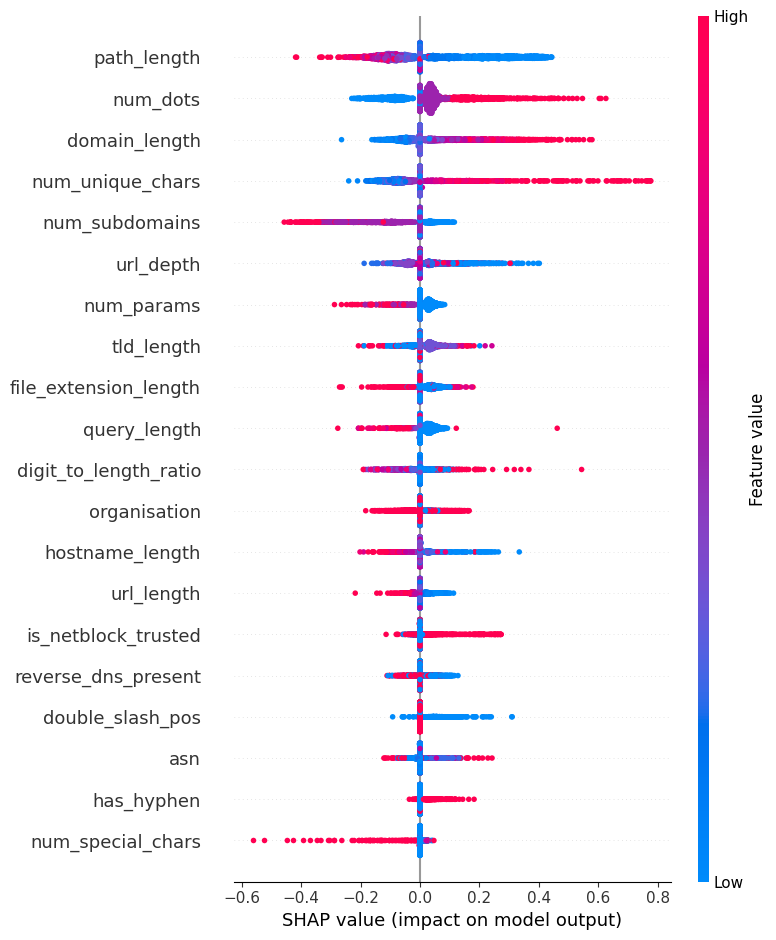

In [ ]:
import shap
shap.initjs()

# Use a small subset of training data as background (e.g., 10 samples)
background = X_train.sample(10).values  # numpy array, shape (10, n_features)

# Define a prediction function for SHAP (expects numpy input, returns probs)
def cnn_predict_proba_shap(data_numpy):
    # data_numpy shape: (batch_size, n_features)
    model_input = torch.tensor(data_numpy, dtype=torch.float32).unsqueeze(1)  # add channel dim
    cnn_model.eval()
    with torch.no_grad():
        outputs = cnn_model(model_input)
        probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()

# Initialize SHAP KernelExplainer
explainer = shap.KernelExplainer(cnn_predict_proba_shap, background)

# Take a subset of test samples to explain (e.g., 100 samples max)
X_test_subset = X_test.head(2500)

# Compute SHAP values (slow! KernelExplainer is computationally expensive)
shap_values = explainer.shap_values(X_test_subset)

print("X_test_subset shape:", X_test_subset.shape)
print("shap_values type:", type(shap_values))
print("Number of classes (length of shap_values):", len(shap_values))
print("Shape of shap_values[0]:", shap_values[0].shape)
print("Shape of shap_values[1]:", shap_values[1].shape)


shap.summary_plot(shap_values[:, :, 1], X_test_subset, feature_names=selected_features)



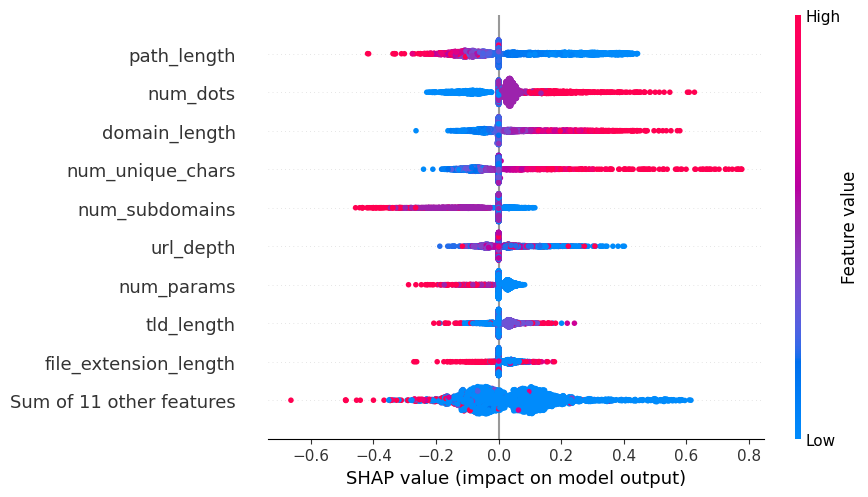

In [ ]:
expl = shap.Explanation(values=shap_values[:, :, 1],
                       base_values=None,   # Optional, can provide background expectation if you have it
                       data=X_test_subset.values,
                       feature_names=selected_features)

shap.plots.beeswarm(expl)

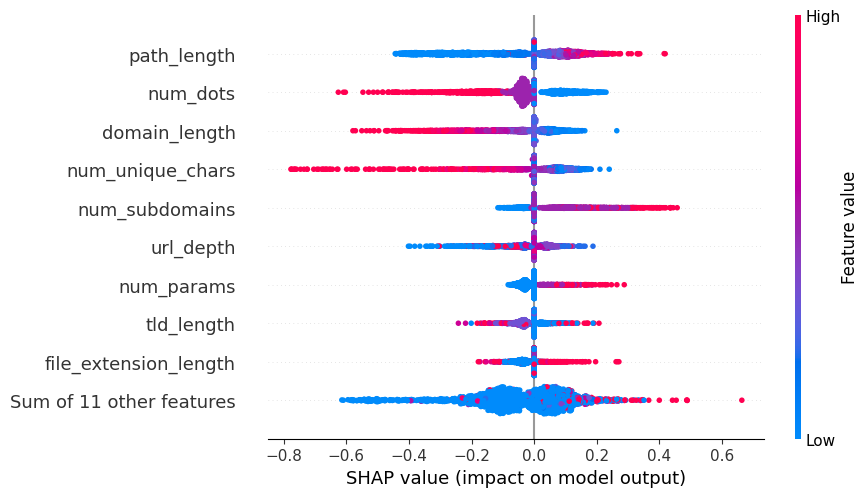

In [ ]:
expl = shap.Explanation(values=shap_values[:, :, 0],
                       base_values=None,   # Optional, can provide background expectation if you have it
                       data=X_test_subset.values,
                       feature_names=selected_features)

shap.plots.beeswarm(expl)

In [ ]:
tabnet_clf = TabNetClassifier()

tabnet_clf.fit(
    X_train=X_train.values,           # convert DataFrame to NumPy array
    y_train=y_train,                  # if y_train is already np.array or Series, it's fine
    eval_set=[(X_test.values, y_test)],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0
)

y_pred = tabnet_clf.predict(X_test.values)

print("TabNet Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")


In [ ]:
# Cell C: Layer 1 - Enhanced Random Forest and XGBoost Base Models
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_predict
import numpy as np

# Initialize enhanced base models with better hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric='logloss'
)

# Train base models and get out-of-fold predictions (using 10-fold CV for better generalization)
# Use existing X_train and y_train from your preprocessing
rf_train_preds = cross_val_predict(rf_model, X_train, y_train, cv=10, method='predict_proba')
xgb_train_preds = cross_val_predict(xgb_model, X_train, y_train, cv=10, method='predict_proba')

# Fit models on full training set for test predictions
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Get test predictions (both probability classes for richer information)
# Use existing X_test from your preprocessing
rf_test_preds = rf_model.predict_proba(X_test)
xgb_test_preds = xgb_model.predict_proba(X_test)

# Create enhanced stacked features with both probability classes
X_train_stacked = np.column_stack([
    rf_train_preds[:, 0], rf_train_preds[:, 1],
    xgb_train_preds[:, 0], xgb_train_preds[:, 1]
])

X_test_stacked = np.column_stack([
    rf_test_preds[:, 0], rf_test_preds[:, 1],
    xgb_test_preds[:, 0], xgb_test_preds[:, 1]
])

print(f"Stacked training features shape: {X_train_stacked.shape}")
print(f"Stacked test features shape: {X_test_stacked.shape}")

In [ ]:
# Cell D: Layer 2 - Enhanced CNN 1D Meta-learner (using existing tensors structure)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

class Enhanced_CNN1D_MetaLearner(nn.Module):
    def __init__(self, input_dim):
        super(Enhanced_CNN1D_MetaLearner, self).__init__()
        # Enhanced convolution layers
        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=2, padding=1)

        # Batch normalization for stable training
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(256)

        # Global pooling
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)

        # Enhanced fully connected layers
        self.fc1 = nn.Linear(512, 256)  # 256*2 for avg+max pooling
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)

        # Dropout for regularization
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.4)
        self.dropout3 = nn.Dropout(0.2)

        self.out = nn.Linear(64, 2)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension

        # Convolutional layers with batch norm and activation
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.dropout1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout2(x)

        x = F.relu(self.bn3(self.conv3(x)))

        # Global pooling (both avg and max)
        avg_pool = self.global_avg_pool(x)
        max_pool = self.global_max_pool(x)

        # Concatenate pooled features
        x = torch.cat([avg_pool, max_pool], dim=1)
        x = x.view(x.size(0), -1)

        # Fully connected layers with dropout
        x = F.relu(self.fc1(x))
        x = self.dropout3(x)

        x = F.relu(self.fc2(x))
        x = self.dropout3(x)

        x = F.relu(self.fc3(x))

        return self.out(x)

# Convert stacked features to PyTorch tensors (following your existing pattern)
X_train_stacked_tensor = torch.tensor(X_train_stacked, dtype=torch.float32)
X_test_stacked_tensor = torch.tensor(X_test_stacked, dtype=torch.float32)

# Use existing y_train_tensor and y_test_tensor from your preprocessing
train_stacked_ds = TensorDataset(X_train_stacked_tensor, y_train_tensor)
test_stacked_ds = TensorDataset(X_test_stacked_tensor, y_test_tensor)
train_stacked_dl = DataLoader(train_stacked_ds, batch_size=64, shuffle=True)
test_stacked_dl = DataLoader(test_stacked_ds, batch_size=64)

# Initialize enhanced meta-learner
meta_cnn = Enhanced_CNN1D_MetaLearner(X_train_stacked.shape[1])

# Enhanced training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(meta_cnn.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

# Training with early stopping
best_loss = float('inf')
patience_counter = 0
patience = 25

for epoch in range(100):
    meta_cnn.train()
    train_loss = 0

    for xb, yb in train_stacked_dl:
        optimizer.zero_grad()
        preds = meta_cnn(xb)
        loss = criterion(preds, yb)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(meta_cnn.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

    # Validation
    meta_cnn.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_stacked_dl:
            preds = meta_cnn(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_stacked_dl)
    scheduler.step(avg_val_loss)

    # Early stopping
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        patience_counter = 0
        best_model_state = meta_cnn.state_dict().copy()
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: Train Loss: {train_loss/len(train_stacked_dl):.4f}, Val Loss: {avg_val_loss:.4f}")

# Load best model
meta_cnn.load_state_dict(best_model_state)
print("Enhanced CNN 1D meta-learner training completed")

In [ ]:
# Cell E: Evaluation and Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Get final predictions using existing y_test from your preprocessing
meta_cnn.eval()
with torch.no_grad():
    final_preds = meta_cnn(X_test_stacked_tensor)
    y_pred_final = final_preds.argmax(dim=1).numpy()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

print("=== ENHANCED STACKING MODEL PERFORMANCE ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_pred_final))